In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dynamic_routing_analysis import decoding_utils
from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
# import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib notebook

In [2]:
results_path="s3://aind-scratch-data/dynamic-routing/decoding/results/expert_baseline_context_500ms_leave_2_blocks_out_half_block_shifts_wraparound_10_units_strict_drift_20260806_185448/"
residuals_results_path="s3://aind-scratch-data/dynamic-routing/decoding/results/test_decoding_from_glm_residuals_20260811_180909/"

session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
# session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.288.naive.parquet"
# session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.289.parquet"


session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    # pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    pl.col('is_opto_perturbation').eq(False),
    pl.col('is_injection_perturbation').eq(False),
    pl.col('is_context_naive').eq(False),
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
    'n_engaged_blocks':[],
}

for sel_session in dr_session_list:
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)
    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    good_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2 and n_engaged_blocks>=4')['session_id'].values

In [4]:
results_session_pd=decoding_utils.load_session_wise_decoder_accuracy(results_path, dr_session_list, session_table, use_linear_shift=False).to_pandas()
residuals_results_session_pd=decoding_utils.load_session_wise_decoder_accuracy(residuals_results_path, dr_session_list, session_table, use_linear_shift=False).to_pandas()

In [5]:
merged_session_results = pd.merge(results_session_pd, residuals_results_session_pd, on=['session_id','structure','unit_subsample_size'], suffixes=('_orig','_glm_resid'), how='right')

In [10]:
merged_session_results.query('mean_true_orig.isna() or mean_true_glm_resid.isna()')

,cross_modality_dprime_vis_blocks_orig,structure,session_id,bin_center_orig,n_passing_blocks_orig,cross_modality_dprime_aud_blocks_orig,time_aligned_to_orig,unit_subsample_size,total_n_units_orig,bin_size_orig,mean_true_orig,cross_modality_dprime_vis_blocks_glm_resid,bin_center_glm_resid,n_passing_blocks_glm_resid,cross_modality_dprime_aud_blocks_glm_resid,time_aligned_to_glm_resid,total_n_units_glm_resid,bin_size_glm_resid,mean_true_glm_resid


Text(0.5, 1.0, 'MOs; Pearson r=0.80, p=1.59e-10;\nmean accuracy diff=0.022')

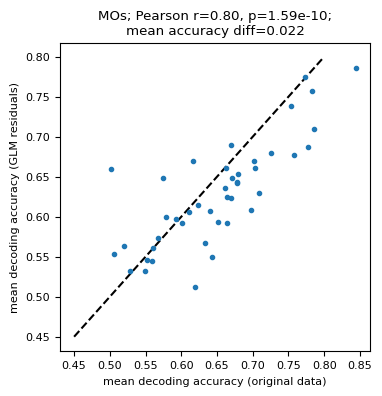

In [7]:
sel_structure='MOs'
mean_true_orig=merged_session_results.query('structure==@sel_structure')['mean_true_orig']
mean_true_glm_resid=merged_session_results.query('structure==@sel_structure')['mean_true_glm_resid']
fig,ax=plt.subplots(1,1,figsize=(4,4))
ax.plot([0.45,0.8],[0.45,0.8],'k--')
ax.plot(mean_true_orig,mean_true_glm_resid,'.')

ax.set_xlabel('mean decoding accuracy (original data)')
ax.set_ylabel('mean decoding accuracy (GLM residuals)')
r,p=stats.pearsonr(mean_true_orig, mean_true_glm_resid)
mean_diff = (mean_true_orig - mean_true_glm_resid).mean()
# mean_diff = (mean_true_glm_resid/mean_true_orig).mean()

ax.set_title(f'{sel_structure}; Pearson r={r:.2f}, p={p:.2e};\nmean accuracy diff={mean_diff:.3f}')

In [16]:
# get the mean for each structure across matched sessions

mean_results_by_structure = merged_session_results.groupby('structure')[['mean_true_orig','mean_true_glm_resid']].mean().reset_index()
mean_results_by_structure['n_sessions'] = merged_session_results.groupby('structure').size().values
mean_results_by_structure['mean_diff'] = mean_results_by_structure['mean_true_orig'] - mean_results_by_structure['mean_true_glm_resid']
mean_results_by_structure.sort_values('mean_diff', ascending=False, inplace=True)
mean_results_by_structure.query('n_sessions>=3')



,structure,mean_true_orig,mean_true_glm_resid,n_sessions,mean_diff
32,GPe,0.742475,0.678252,5,0.064223
12,AUDp,0.599713,0.544081,4,0.055632
59,PAG,0.689068,0.646436,5,0.042632
66,POL,0.618847,0.577165,6,0.041682
29,Eth,0.615899,0.575040,5,0.040859
...,...,...,...,...,...
82,SGN,0.542777,0.550315,8,-0.007539
49,MOB,0.526142,0.541586,3,-0.015444
10,APN,0.570387,0.595632,7,-0.025246
99,VISpor,0.532135,0.566111,5,-0.033976


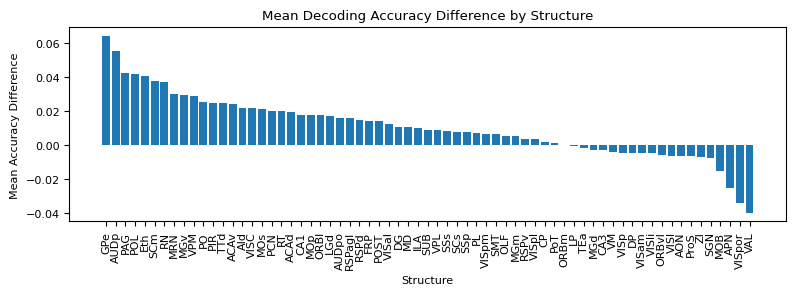

In [19]:
min_n_sessions=3
fig,ax = plt.subplots(1,1,figsize=(8,3))
ax.bar(mean_results_by_structure.query('n_sessions>=@min_n_sessions')['structure'], mean_results_by_structure.query('n_sessions>=@min_n_sessions')['mean_diff'])
ax.set_xlabel('Structure')
ax.set_ylabel('Mean Accuracy Difference')
ax.set_title('Mean Decoding Accuracy Difference by Structure')
plt.xticks(rotation=90)
plt.tight_layout()

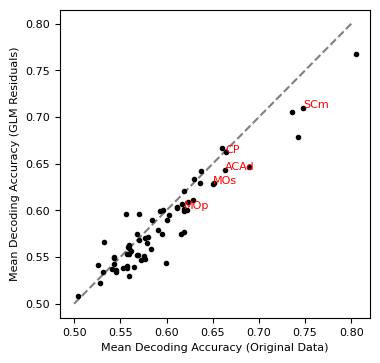

In [30]:
label_structures=['SCm','CP','MOp','MOs','ACAd']
fig,ax=plt.subplots(figsize=(4,4))
ax.plot([0.5,0.8],[0.5,0.8],'k--',alpha=0.5)
ax.plot(mean_results_by_structure.query('n_sessions>=@min_n_sessions')['mean_true_orig'], mean_results_by_structure.query('n_sessions>=@min_n_sessions')['mean_true_glm_resid'], 'k.')
ax.set_xlabel('Mean Decoding Accuracy (Original Data)')
ax.set_ylabel('Mean Decoding Accuracy (GLM Residuals)')
# ax.set_title('Comparison of Mean Decoding Accuracy by Structure')
# ax.plot([0,1],[0,1],'k--')
for structure in label_structures:
    subset = mean_results_by_structure.query('n_sessions>=@min_n_sessions and structure==@structure')
    if not subset.empty:
        ax.text(subset['mean_true_orig'].values[0], subset['mean_true_glm_resid'].values[0], structure, fontsize=8, color='r')
